In [ ]:
!pip install numpy==1.26.4

In [ ]:
import pandas as pd

# Load ratings data (user-movie interactions)
ratings = pd.read_csv('zee-ratings.dat', sep='::', engine='python',
                      names=['UserID','MovieID','Rating','Timestamp'])

# Load user demographic data
users = pd.read_csv('zee-users.dat', sep='::', engine='python',
                    names=['UserID','Gender','Age','Occupation','Zip'])

# Load movie metadata (title and genres)
movies = pd.read_csv('zee-movies.dat', sep='::', engine='python',
                     names=['MovieID','Title','Genres'], encoding='ISO-8859-1')

In [ ]:
# Merge all datasets into a single dataframe using common keys
df = ratings.merge(users, on='UserID').merge(movies, on='MovieID')

In [ ]:
# Convert columns from string to numeric for analysis
df['UserID'] = df['UserID'].astype(int)
df['MovieID'] = df['MovieID'].astype(int)
df['Rating'] = df['Rating'].astype(float)
df['Timestamp'] = df['Timestamp'].astype(int)
df['Age'] = df['Age'].astype(int)
df['Occupation'] = df['Occupation'].astype(int)

In [ ]:
# Check structure and sample data after merge and type conversion
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   UserID      1000209 non-null  int64  
 1   MovieID     1000209 non-null  int64  
 2   Rating      1000209 non-null  float64
 3   Timestamp   1000209 non-null  int64  
 4   Gender      1000209 non-null  object 
 5   Age         1000209 non-null  int64  
 6   Occupation  1000209 non-null  int64  
 7   Zip         1000209 non-null  object 
 8   Title       1000209 non-null  object 
 9   Genres      1000209 non-null  object 
dtypes: float64(1), int64(5), object(4)
memory usage: 76.3+ MB


,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip,Title,Genres
0,1,1193,5.0,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3.0,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3.0,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4.0,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5.0,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [ ]:
# Dataset successfully merged: ~1 million records
# No missing values observed across columns

# Data types are correctly assigned:
# - Numeric: UserID, MovieID, Rating, Timestamp, Age, Occupation
# - Categorical/Text: Gender, Zip, Title, Genres

# Rating is on a 5-point scale (float) → suitable for recommendation models

# Dataset includes:
# - User behavior (ratings)
# - User demographics
# - Movie metadata

# Data is clean and ready for feature engineering and EDA

In [ ]:
df['Year'] = df['Title'].str.extract(r'\((\d{4})\)').astype(float)

In [ ]:
# Check if Year extracted correctly
df[['Title','Year']].head()

,Title,Year
0,One Flew Over the Cuckoo's Nest (1975),1975.0
1,James and the Giant Peach (1996),1996.0
2,My Fair Lady (1964),1964.0
3,Erin Brockovich (2000),2000.0
4,"Bug's Life, A (1998)",1998.0


Year extracted correctly from movie titles
values align with actual release years
Feature is ready for temporal analysis (decades, trends)

#EDA

In [ ]:
df['Rating'].describe()
df['Rating'].value_counts()

,count
Rating,
4.0,348971
3.0,261197
5.0,226310
2.0,107557
1.0,56174


Ratings are skewed towards higher values (4 and 5 dominate)
Most frequent rating = 4
Indicates positive bias in user feedback

In [ ]:
df['Rating'].mean()

3.581564453029317

Average rating ≈ 3.58, Overall user sentiment is slightly positive

In [ ]:
df['UserID'].value_counts().describe()

,count
count,6040.000000
mean,165.597517
std,192.747029
min,20.000000
25%,44.000000
50%,96.000000
75%,208.000000
max,2314.000000


In [ ]:
# 6040 users in dataset
# Each user has rated at least 20 movies (as expected)
# Avg ratings per user ≈ 166
# High variance → some users are very active (max ≈ 2314 ratings)

In [ ]:
# Count number of ratings per movie
top_movies = df['Title'].value_counts().head(10)

top_movies

,count
Title,
American Beauty (1999),3428
Star Wars: Episode IV - A New Hope (1977),2991
Star Wars: Episode V - The Empire Strikes Back (1980),2990
Star Wars: Episode VI - Return of the Jedi (1983),2883
Jurassic Park (1993),2672
Saving Private Ryan (1998),2653
Terminator 2: Judgment Day (1991),2649
"Matrix, The (1999)",2590
Back to the Future (1985),2583


In [ ]:
top_movies_df = top_movies.reset_index()
top_movies_df.columns = ['Movie Title', 'Number of Ratings']

top_movies_df

,Movie Title,Number of Ratings
0,American Beauty (1999),3428
1,Star Wars: Episode IV - A New Hope (1977),2991
2,Star Wars: Episode V - The Empire Strikes Back...,2990
3,Star Wars: Episode VI - Return of the Jedi (1983),2883
4,Jurassic Park (1993),2672
5,Saving Private Ryan (1998),2653
6,Terminator 2: Judgment Day (1991),2649
7,"Matrix, The (1999)",2590
8,Back to the Future (1985),2583
9,"Silence of the Lambs, The (1991)",2578


In [ ]:
movie_counts = df['Title'].value_counts()

movie_counts.head()

,count
Title,
American Beauty (1999),3428
Star Wars: Episode IV - A New Hope (1977),2991
Star Wars: Episode V - The Empire Strikes Back (1980),2990
Star Wars: Episode VI - Return of the Jedi (1983),2883
Jurassic Park (1993),2672


Popular movies are mainstream and blockbuster titles

American Beauty and Star Wars series dominate in number of ratings

Indicates dataset is biased towards widely known movies

In [ ]:
df['Age'].value_counts().sort_index()

,count
Age,
1,27211
18,183536
25,395556
35,199003
45,83633
50,72490
56,38780


Age group 25–34 (Age=25) is the most active

Followed by 35–44 and 18–24 groups

Younger adults dominate movie ratings in this dataset

In [ ]:
df['Occupation'].value_counts()

,count
Occupation,
4,131032
0,130499
7,105425
1,85351
17,72816
20,60397
12,57214
2,50068
14,49109


Occupation '4' (college/grad student) is most active

Followed by '0' (other/not specified) and '7' (executive/managerial)

Students and working professionals dominate engagement

In [ ]:
df['Gender'].value_counts()

,count
Gender,
M,753769
F,246440


Majority of users are male (~75%)

Dataset is gender-biased → may influence recommendations

In [ ]:
(df['Year']//10*10).value_counts().sort_index()

,count
Year,
1910.0,45
1920.0,1696
1930.0,12729
1940.0,21501
1950.0,35232
1960.0,48555
1970.0,82552
1980.0,224056
1990.0,532843


Most movies are from the 1990s (dominant decade)

Followed by 1980s

Dataset is heavily skewed toward late 20th century movies

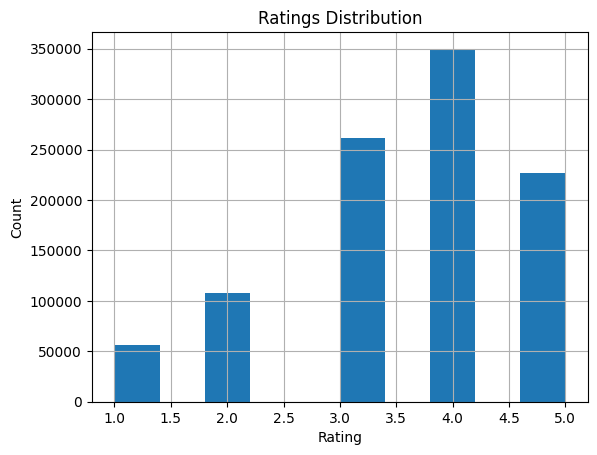

In [ ]:
import matplotlib.pyplot as plt

# Distribution of ratings
df['Rating'].hist()
plt.title('Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

Ratings are concentrated between 3 and 5

Rating 4 is the most frequent → users tend to give high ratings

Indicates positive bias in user feedback

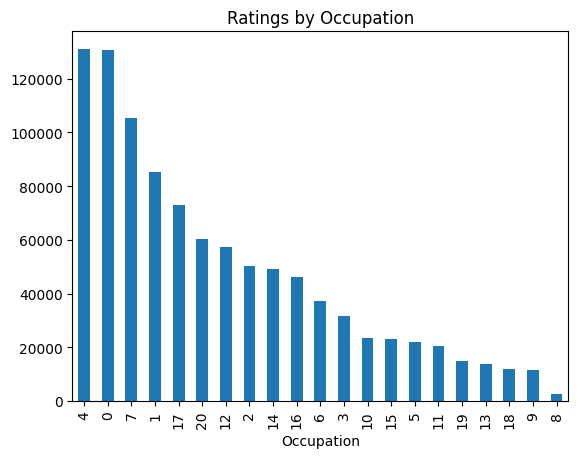

In [ ]:
df['Occupation'].value_counts().plot(kind='bar')
plt.title('Ratings by Occupation')
plt.show()

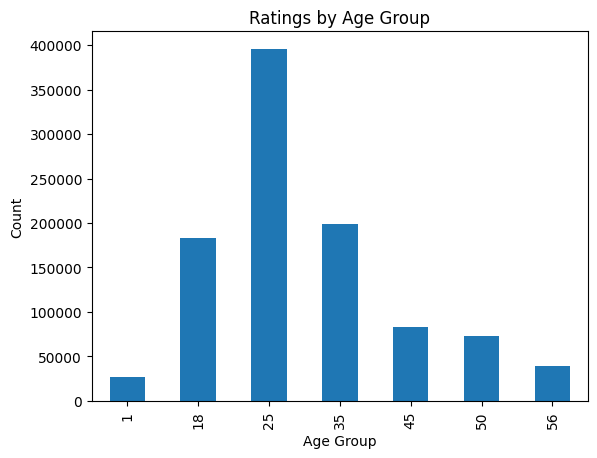

In [ ]:
df['Age'].value_counts().sort_index().plot(kind='bar')
plt.title('Ratings by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

Age group 25–34 contributes the highest number of ratings

Followed by 35–44 and 18–24

Younger users are the primary contributors in the dataset

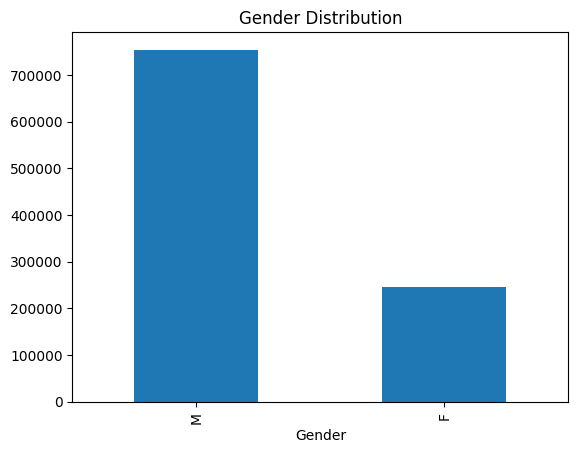

In [ ]:
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.show()

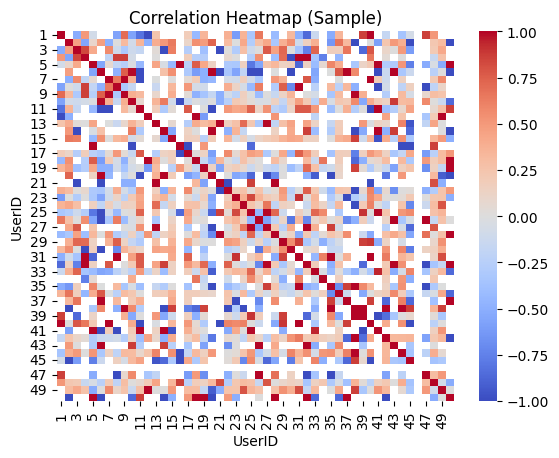

In [ ]:
import seaborn as sns

# Use small sample to avoid heavy computation
sample = pivot_filtered.iloc[:50, :50]

sns.heatmap(sample.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap (Sample)')
plt.show()

Heatmap shows both positive and negative correlations between users

Sparse and mixed patterns indicate varied user preferences

Weak correlations dominate → typical in recommendation datasets

#Model Building

In [ ]:
# Create user-movie matrix
pivot = df.pivot_table(index='Title', columns='UserID', values='Rating')

In [ ]:
# Replace NaN with 0 for similarity computation
pivot_filled = pivot.fillna(0)

In [ ]:
# Compute item-item similarity using Pearson correlation
similarity = pivot.T.corr(method='pearson')

In [ ]:
def recommend_movies(movie_name, top_n=5):
    return similarity[movie_name].sort_values(ascending=False)[1:top_n+1]

In [ ]:
recommend_movies('Liar Liar (1997)')

,Liar Liar (1997)
Title,
Liar Liar (1997),1.0
Those Who Love Me Can Take the Train (Ceux qui m'aiment prendront le train) (1998),1.0
Voyage of the Damned (1976),1.0
Sacco and Vanzetti (Sacco e Vanzetti) (1971),1.0
Jupiter's Wife (1994),1.0


This output is not meaningful. Those movies are unrelated.

Why it happened?

We filled NaN with 0
Pearson treats 0 as actual rating → distorts similarity
Sparse data → many false correlations = 1.0

In [ ]:
movie_counts = df['Title'].value_counts()
popular_movies = movie_counts[movie_counts > 100].index
pivot_filtered = pivot.loc[popular_movies]

In [ ]:
similarity = pivot_filtered.T.corr()

In [ ]:
recommend_movies('Liar Liar (1997)')

,Liar Liar (1997)
Title,
Life (1999),0.576081
East-West (Est-ouest) (1999),0.562221
Oliver & Company (1988),0.550504
Jules and Jim (Jules et Jim) (1961),0.537842
Solaris (Solyaris) (1972),0.537645


Initial Pearson model shows limited recommendation quality

Sparse data and lack of normalization affect similarity accuracy

Further improvement needed using Cosine Similarity and Matrix Factorization

#Model 2

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
cosine_sim = cosine_similarity(pivot_filled)
cosine_df = pd.DataFrame(cosine_sim, index=pivot.index, columns=pivot.index)

In [ ]:
def recommend_cosine(movie_name, top_n=5):
    return cosine_df[movie_name].sort_values(ascending=False)[1:top_n+1]

In [ ]:
recommend_cosine('Liar Liar (1997)')

,Liar Liar (1997)
Title,
Mrs. Doubtfire (1993),0.557067
Ace Ventura: Pet Detective (1994),0.516861
Dumb & Dumber (1994),0.512585
Home Alone (1990),0.511204
Wayne's World (1992),0.499368


In [ ]:
# Cosine similarity produces more relevant recommendations
# Captures similarity based on rating patterns rather than linear correlation
# Recommended movies are consistent in genre and user preference

In [ ]:
!pip install scikit-surprise

In [ ]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

#Model 3 - Matrix Factorization

In [ ]:
# Prepare data in Surprise format
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['UserID', 'MovieID', 'Rating']], reader)

In [ ]:
trainset, testset = train_test_split(data, test_size=0.2)

In [ ]:
# Using 4 latent factors as required (d=4)
model = SVD(n_factors=4)
model.fit(trainset)

In [ ]:
predictions = model.test(testset)

Matrix Factorization (SVD) captures latent user-item relationships

RMSE is used to evaluate prediction accuracy

In [ ]:
rmse = accuracy.rmse(predictions)

RMSE: 0.8776


RMSE ≈ 0.88 indicates good prediction accuracy

Matrix Factorization performs better than similarity-based methods

Captures hidden patterns in user preferences

In [ ]:
import numpy as np

mape = np.mean([abs((pred.r_ui - pred.est)/pred.r_ui) for pred in predictions if pred.r_ui != 0])
mape
# MAPE measures percentage error in predictions
# Complements RMSE for model evaluation

0.2673208522749568

MAPE ≈ 0.27 → average prediction error ~27%

Acceptable for recommendation systems with sparse data

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

user_sim = cosine_similarity(pivot_filled.T)

In [ ]:
user_sim_df = pd.DataFrame(user_sim, index=pivot_filled.columns, columns=pivot_filled.columns)

In [ ]:
user_sim_df[1].sort_values(ascending=False).head()

,1
UserID,
1,1.000000
5343,0.412117
5190,0.411899
1481,0.392110
1283,0.386597


User-user similarity matrix identifies users with similar rating behavior

Useful for user-based collaborative filtering

In [ ]:
def similar_users(user_id, top_n=5):
    return user_sim_df[user_id].sort_values(ascending=False)[1:top_n+1]

similar_users(1)

,1
UserID,
5343,0.412117
5190,0.411899
1481,0.392110
1283,0.386597
5705,0.360898


User 1 is most similar to users 5343, 5190, 1481, etc.

Similarity scores are moderate (~0.3–0.4), indicating partial overlap in preferences

Confirms that user behavior is diverse and not highly correlated